In [ ]:
"""
Gustavo Bernard Oliveira Schwarz
nUSP 4614284
"""

In [9]:
import numpy as np
from qiskit_aer import AerSimulator

from qiskit import QuantumCircuit, transpile
from qiskit.quantum_info import Statevector
from qiskit.visualization import plot_state_qsphere,plot_histogram

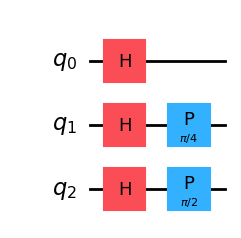

<IPython.core.display.Latex object>

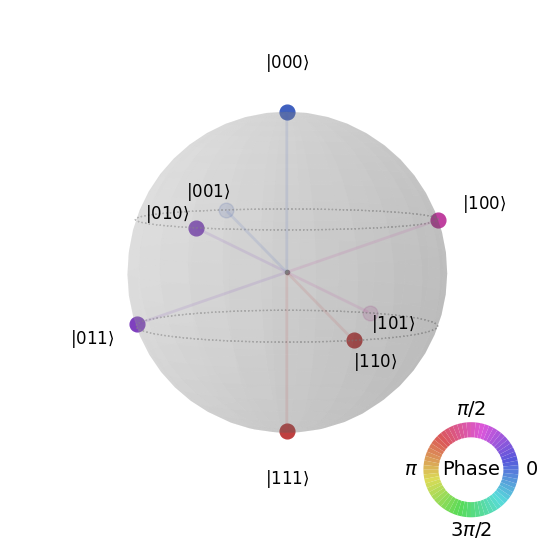

In [ ]:
"""
1) Construa um circuito quântico de 3 qubits e utilize as portas quânticas
necessárias para: criar uma superposição equiprovável dos 8 estados da base
computacional e alterar as fases dos estados da seguinte forma: |0⟩ e |1⟩ (fase 0), |2⟩ e |3⟩
(fase 𝜋/4), |4⟩ e |5⟩ (fase 𝜋/2), |6⟩ e |7⟩ (fase 3𝜋/4). Utilize a Qsphere para facilitar a
visualização dos estados e fases.
"""

qc = QuantumCircuit(3)

# colocando os 3 qubits em superposição
qc.h(0)
qc.h(1)
qc.h(2)

# Na base |q2 q1 q0>, a fase desejada é:
#     phi = q1*pi/4 + q2*pi/2
#
# Assim:
# q2q1 = 00 -> 0
# q2q1 = 01 -> pi/4
# q2q1 = 10 -> pi/2
# q2q1 = 11 -> 3*pi/4
#
# Portanto, bastam P(pi/4) em q1 e P(pi/2) em q2.

qc.p(np.pi / 4, 1)
qc.p(np.pi / 2, 2)


display(qc.draw("mpl"))
state = Statevector.from_instruction(qc)
display(state.draw("latex"))

plot_state_qsphere(state)

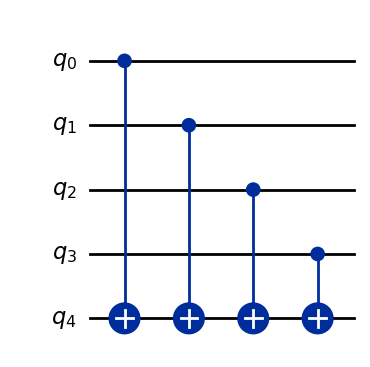

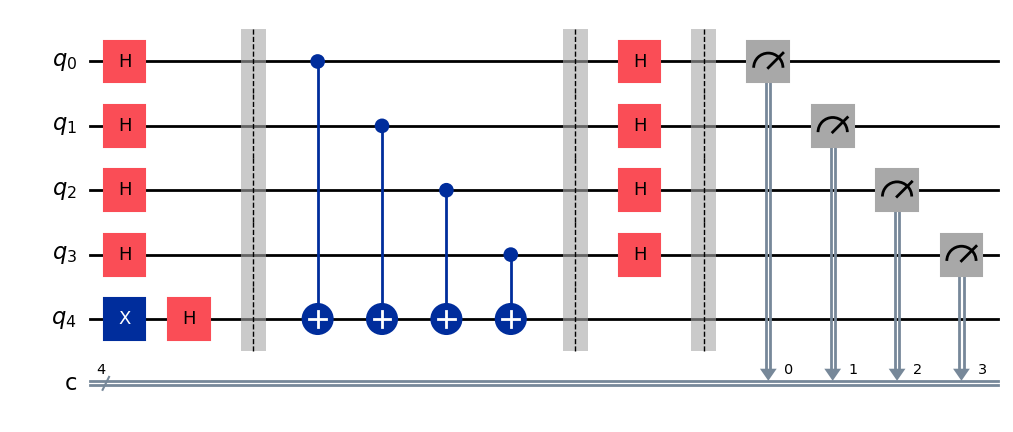

{'1111': 1024}


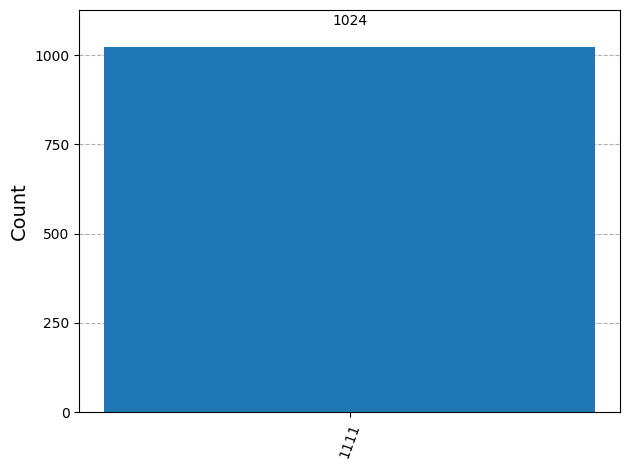

A função é balanceada


In [ ]:
"""
2) Os itens abaixo são referentes aos oráculos e algoritmo de Deutsch-Jozsa. Para
cada item, apresente o código, o diagrama de circuito e o resultado do simulador:


a) Conforme o método apresentado em aula, construa um oráculo de Deutsch-Jozsa
com n = 5 qubits que implemente a seguinte função balanceada de 4 bits. Execute o
algoritmo de Deutsch-Jozsa utilizando esse oráculo e verifique que o resultado representa
de fato uma função balanceada.
"""


"""
dá para identificar a função olhando a tabela. Por exemplo:

f(0000)=0
f(0001)=1
f(0010)=1
f(0011)=0

f(x)=q_0 XOR q_1 XOR q_2 XOR q_3
"""

oracle = QuantumCircuit(5, name="Uf")

# q0, q1, q2, q3 = entrada
# q4 = ancilla
for q in range(4):
    oracle.cx(q, 4)

display(oracle.draw("mpl"))

dj = QuantumCircuit(5, 4)

# Ancilla inicialmente em |1>
dj.x(4)

# Hadamard em todos os qubits
for q in range(5):
    dj.h(q)

dj.barrier()

# Aplica o oráculo
dj.compose(oracle, inplace=True)
dj.barrier()

# Hadamard novamente apenas nos qubits de entrada
for q in range(4):
    dj.h(q)

dj.barrier()

# Mede somente o registrador de entrada
for q in range(4):
    dj.measure(q, q)

# Mostra o circuito completo
display(dj.draw("mpl"))

simulator = AerSimulator()

compiled = transpile(dj, simulator)

result = simulator.run(
    compiled,
    shots=1024
).result()

counts = result.get_counts()

print(counts)

display(plot_histogram(counts))

if counts.get("0000", 0) == 1024:
    print("A função é constante")
else:
    print("A função é balanceada")

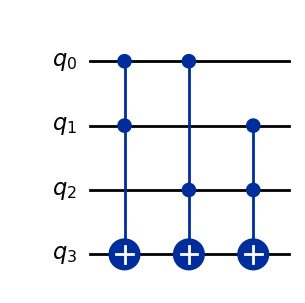

{'100': 1034, '001': 1021, '010': 1041, '111': 1000}


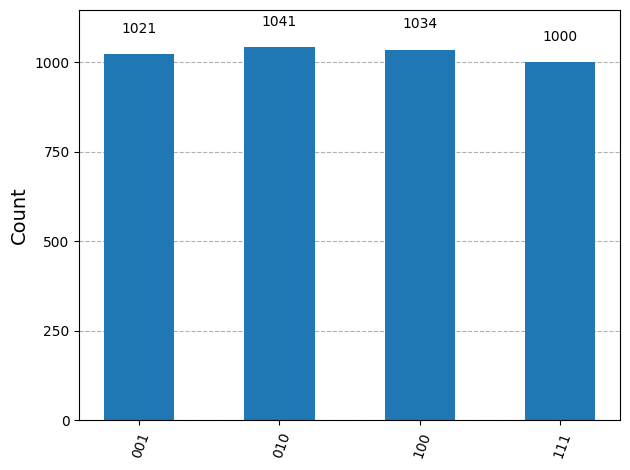

In [ ]:
"""
b) Construa um oráculo de Deutsch-Jozsa com n = 4 qubits que implemente uma
função balanceada de 3 bits utilizando apenas portas CCX. Execute o algoritmo de
Deutsch-Jozsa utilizando esse oráculo e verifique que o resultado representa de fato uma
função balanceada.
"""

oracle = QuantumCircuit(4, name="Uf")

# q0, q1, q2 = entrada
# q3 = ancilla

oracle.ccx(0, 1, 3)
oracle.ccx(0, 2, 3)
oracle.ccx(1, 2, 3)

display(oracle.draw("mpl"))

dj = QuantumCircuit(4, 3)
dj.x(3) # ancilla inicialmente em |1>

# coloco tudo em superposicao
for q in range(4):
    dj.h(q)
dj.barrier()

dj.compose(oracle, inplace=True)
dj.barrier()

# hadamard novamente
for q in range(3):
    dj.h(q)
dj.barrier()

for q in range(3):
    dj.measure(q, q)

# simulacao
simulator = AerSimulator()
compiled = transpile(dj, simulator)
result = simulator.run(
    compiled,
    shots=4096
).result()

counts = result.get_counts()
print(counts)
display(plot_histogram(counts))

# O estado 000 não é observado, ou seja, P(000) = 0.
# Pelo algoritmo de Deutsch-Jozsa, isso indica que a função implementada
# pelo oráculo é balanceada, confirmando o resultado esperado.

Oráculo 1: {'1111': 1024}
Função BALANCEADA


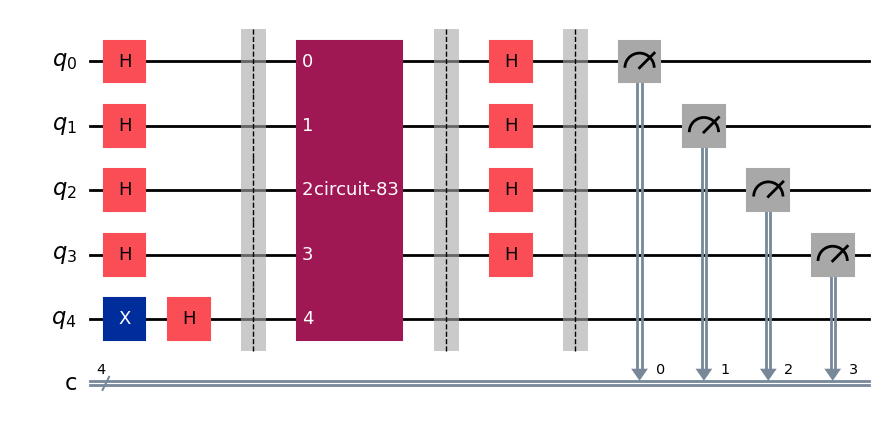

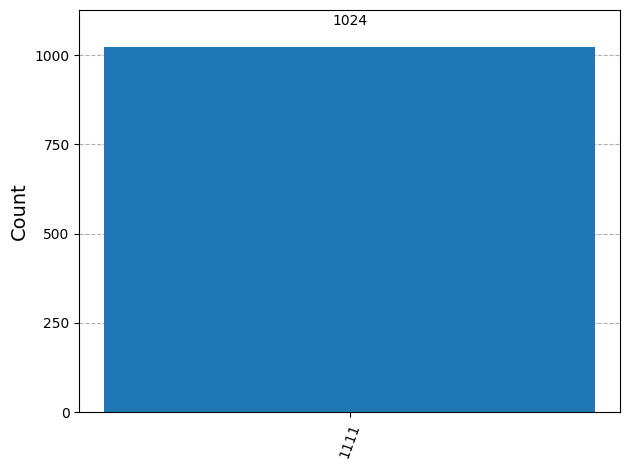

Oráculo 2: {'0000': 1024}
Função CONSTANTE


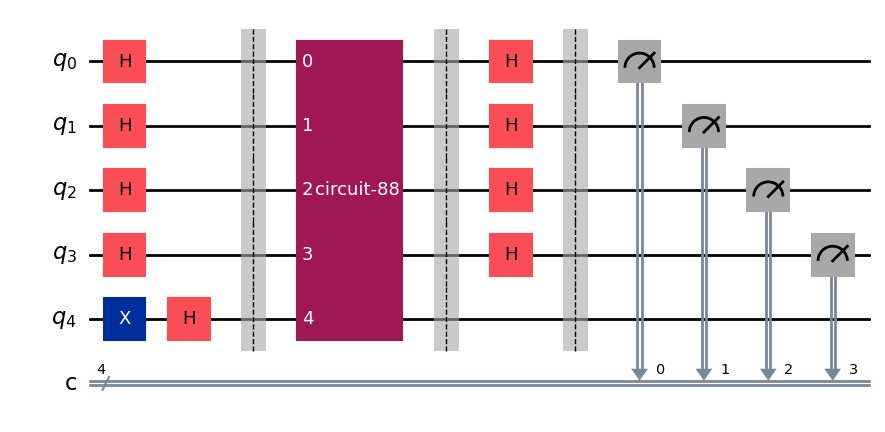

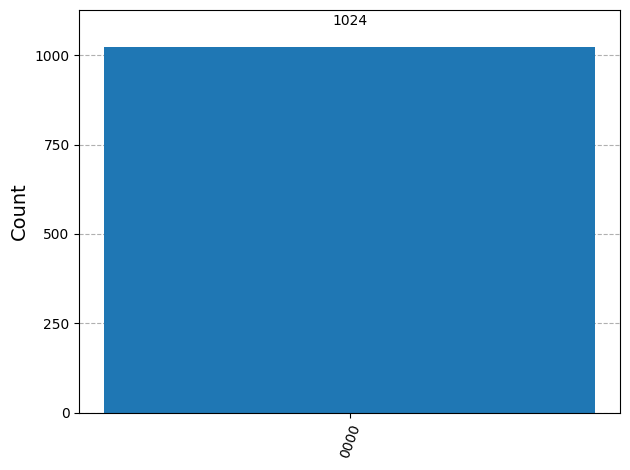

Oráculo 3: {'1101': 262, '0011': 274, '1111': 240, '0001': 248}
Função BALANCEADA


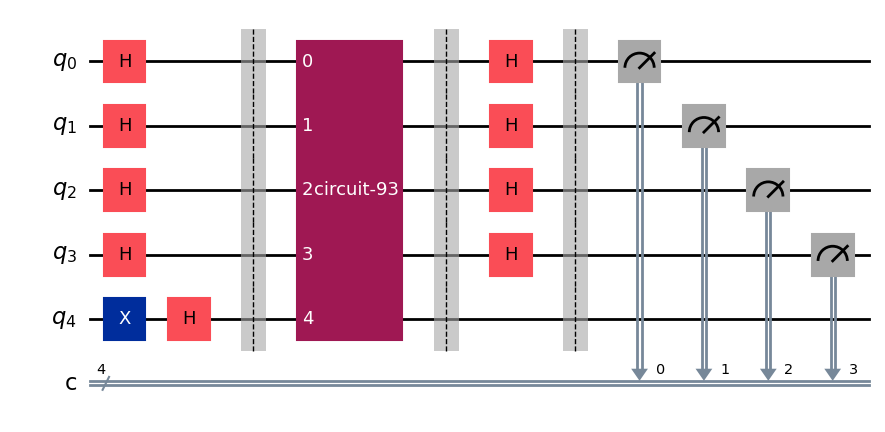

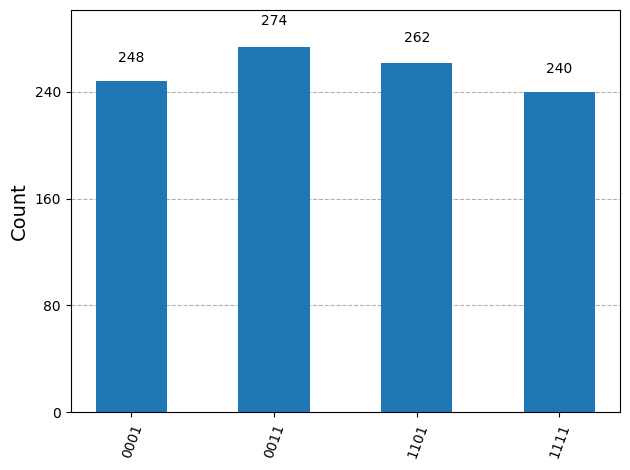

Oráculo 4: {'0100': 1024}
Função BALANCEADA


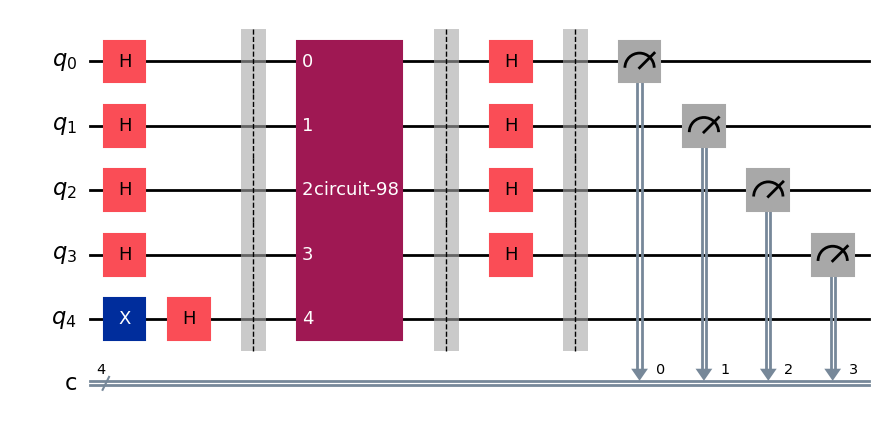

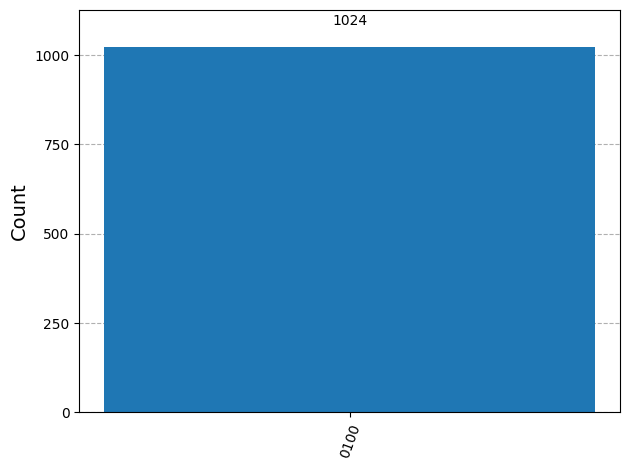

In [24]:
"""
c) A função dj_problem
_
oracle apresentada no trecho de código abaixo retorna um
oráculo de Deutsch-Jozsa como uma porta quântica. Essa porta recebe 5 qubits de entrada
onde o qubit q4 representa o qubit de saída. A função é parametrizada com um valor inteiro
de 1 a 4, fornecendo quatro oráculos distintos. Utilize o algoritmo de Deutsch-Jozsa para
decidir para cada oráculo se ele é constante ou balanceado.
"""

# instalei o qiskit-textbook de git+https://github.com/qiskit-community/qiskit-textbook.git#subdirectory=qiskit-textbook-src
from qiskit_textbook.problems import dj_problem_oracle

simulator = AerSimulator()

for i in range(1, 5):

    # Oráculo caixa-preta
    oracle = dj_problem_oracle(i)

    # 4 qubits de entrada + q4 ancilla
    dj = QuantumCircuit(5, 4)

    # Ancilla inicialmente em |1>
    dj.x(4)

    # Hadamard em todos
    for q in range(5):
        dj.h(q)

    dj.barrier()

    # Aplica o oráculo
    dj.append(oracle, range(5))

    dj.barrier()

    # Hadamard novamente nos 4 qubits de entrada
    for q in range(4):
        dj.h(q)

    dj.barrier()

    # Mede somente os qubits de entrada
    for q in range(4):
        dj.measure(q, q)

    # Simulação
    compiled = transpile(dj, simulator)

    result = simulator.run(
        compiled,
        shots=1024
    ).result()

    counts = result.get_counts()

    print(f"Oráculo {i}: {counts}")

    # Deutsch-Jozsa
    if counts.get("0000", 0) == 1024:
        print("Função CONSTANTE")
    else:
        print("Função BALANCEADA")

    display(dj.draw("mpl"))
    display(plot_histogram(counts))